In [ ]:
import pandas as pd
import numpy as np
data={
    "Weather":["sunny","sunny","cloudy","rainy","rainy","rainy","cloudy","sunnny","sunny","rainy","sunny","cloudy","cloudy","rainy"],
    'Temperature':['hot','hot','hot','mild','cool','cool','cool','mild','cool','mild','mild','mild','hot','mild'],
    'Soilmoisture':['dry','dry','dry','dry','moist','moist','moist','dry','moist','moist','moist','dry','moist','dry'],
    'Wind':['weak','strong','weak','weak','weak','strong','strong','weak','weak','weak','strong','strong','weak','strong'],
    'Irrigate':['no','no','yes','yes','yes','no','yes','no',' yes','yes','yes','yes','yes','no']
    }

df=pd.DataFrame(data)


def entropy(target):
  values,counts=np.unique(target,return_counts=True)
  prob=counts/counts.sum()
  return -np.sum(prob * np.log2(prob))

def information_gain(data,feature,target_name):
  total_entropy=entropy(data[target_name])
  values,counts=np.unique(data[feature],return_counts=True)
  weighted_entropy=0
  for i in range(len(values)):
    subset=data[data[feature]==values[i]]
    weighted_entropy+=(counts[i]/np.sum(counts))*entropy(subset[target_name])
  return total_entropy - weighted_entropy

def id3(data,features,target_name,depth=0):
  indent="  "*depth
  if len(np.unique(data[target_name]))==1:
     return np.unique(data[target_name])[0]
  if len(features)==0:
      return data[target_name].mode()[0]

  gains=[]
  print(f"\n{indent}Evaluating features at depth {depth}:")
  for feature in features:
    gain=information_gain(data,feature,target_name)
    gains.append(gain)
    print(f"{indent}|G({feature})={gain:.4f}")
  best_feature=features[np.argmax(gains)]
  print(f"{indent}Best Feature --> {best_feature}")

  tree={best_feature:{}}

  for value in np.unique(data[best_feature]):
    print(f"{indent}splitting {best_feature}={value}")
    subset=data[data[best_feature]==value]
    if subset.shape[0]==0:
       tree[best_feature][value]=data[target_name].mode()[0]
    else:
      remaining_features=[f for f in features if f!=best_feature]
      subtree=id3(subset,remaining_features,target_name,depth+1)
      tree[best_feature][value]=subtree
  return tree


def print_tree(tree,indent=""):
  if not isinstance (tree,dict):
    print(indent+"",(tree))
    return
  for feature,branches in tree.items():
    for value ,subtree in branches.items():
      print(f"{indent}{feature}={value}:")
      print_tree(subtree,indent +"  ")

features=list(df.columns[:-1])
tree_model=id3(df,features,'Irrigate')

print("\nFinal Decision Tree:\n")
print_tree(tree_model)



Evaluating features at depth 0:
|G(Weather)=0.4885
|G(Temperature)=0.1560
|G(Soilmoisture)=0.1968
|G(Wind)=0.0931
Best Feature --> Weather
splitting Weather=cloudy
splitting Weather=rainy

  Evaluating features at depth 1:
  |G(Temperature)=0.0200
  |G(Soilmoisture)=0.0200
  |G(Wind)=0.9710
  Best Feature --> Wind
  splitting Wind=strong
  splitting Wind=weak
splitting Weather=sunnny
splitting Weather=sunny

  Evaluating features at depth 1:
  |G(Temperature)=1.5000
  |G(Soilmoisture)=1.0000
  |G(Wind)=0.5000
  Best Feature --> Temperature
  splitting Temperature=cool
  splitting Temperature=hot
  splitting Temperature=mild

Final Decision Tree:

Weather=cloudy:
   yes
Weather=rainy:
  Wind=strong:
     no
  Wind=weak:
     yes
Weather=sunnny:
   no
Weather=sunny:
  Temperature=cool:
      yes
  Temperature=hot:
     no
  Temperature=mild:
     yes


Sample Dataset:
   Weather   Soil Temperature Humidity    Wind Fertilizer Crop Type  Season  \
0   Rainy  Moist         Hot     High    Weak        Yes      Corn    Rabi   
1   Sunny    Dry        Cool      Low    Weak        Yes      Rice    Rabi   
2   Rainy  Moist        Mild   Medium  Strong        Yes      Rice  Kharif   
3   Rainy  Moist        Cool     High  Strong        Yes      Rice  Kharif   
4   Sunny  Moist        Cool     High    Weak         No      Rice  Kharif   

  irrigate  
0       NO  
1      Yes  
2       No  
3       NO  
4       No  

Accuracy Comparison:
Decision Tree accuracy: 0.8888888888888888
Random Forest Accuracy: 0.9444444444444444

Decision Tree Confusion Matrix:
             Pred No  Pred Yes
Actual No         2         0
Actual Yes        0         8

Random Forest Confusion Matrix:
             Pred No  Pred Yes
Actual No         2         0
Actual Yes        0         8


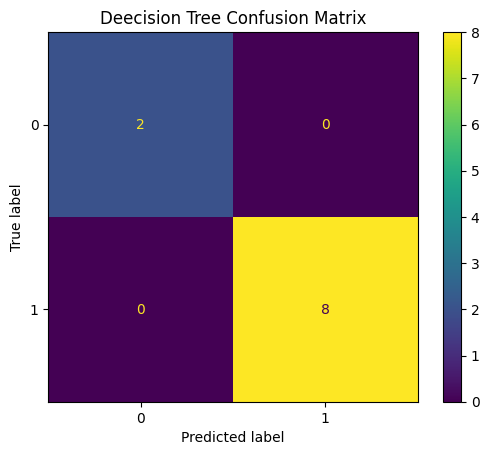

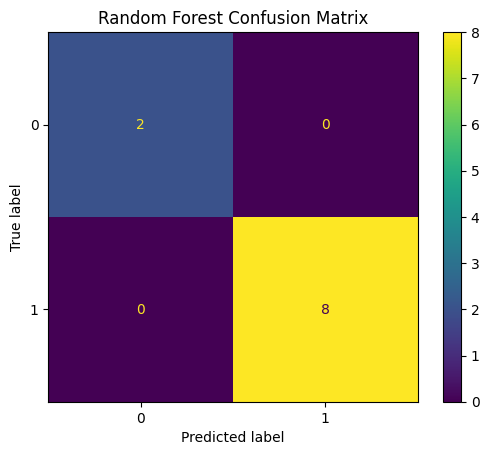


Cross Validation Accuracy
Decision Tree: 0.7833333333333333
Random Forest: 0.75

Feature Importance:
        Feature  Importance
1         Soil    0.272823
3     Humidity    0.188617
0      Weather    0.132826
6    Crop Type    0.121954
7       Season    0.088256
2  Temperature    0.080841
4         Wind    0.057431
5   Fertilizer    0.057253


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
np.random.seed(42)

n_samples=60

data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'Crop Type':np.random.choice(['Wheat','Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
}
df=pd.DataFrame(data)

def irrigate_rule(row):
  if row['Soil']=='Dry'and row["Weather"]!='Rainy':
    return 'Yes'
  elif row['Soil']=='Wet':
    return 'No'
  elif row['Humidity']=='High'and row['Weather']=='Rainy':
    return 'NO'
  else:
    return np.random.choice(['Yes','No'])
df['irrigate']=df.apply(irrigate_rule,axis=1)

print("Sample Dataset:\n",df.head())


le_dict={}
for column in df.columns:
  le=LabelEncoder()
  df[column]=le.fit_transform(df[column])
  le_dict[column]=le

X=df.drop('irrigate',axis=1)
y=df['irrigate']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

rf_model=RandomForestClassifier(n_estimators=20,criterion='entropy',random_state=42)

rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)

print("\nAccuracy Comparison:",)
print("Decision Tree accuracy:",dt_accuracy)
print("Random Forest Accuracy:",rf_accuracy)


cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

cm_dt_df=pd.DataFrame(cm_dt,index=['Actual No','Actual Yes'],columns=['Pred No','Pred Yes'])
cm_rf_df=pd.DataFrame(cm_rf,index=['Actual No','Actual yes'],columns=['Pred No','Pred Yes'])
print("\nDecision Tree Confusion Matrix:\n",cm_dt_df)
print("\nRandom Forest Confusion Matrix:\n",cm_dt_df)


ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Deecision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Random Forest Confusion Matrix")
plt.show()

dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\nCross Validation Accuracy")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())


importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

print("\nFeature Importance:\n",importance)


Accuracy Comparision
Decision Tree Accuracy: 0.5555555555555556
Random Forest Accuracy: 0.6222222222222222

Decision Tree Confusion Matrix: [[25 19]
 [21 25]]

Random forest Confusion Matrix: [[26 18]
 [16 30]]


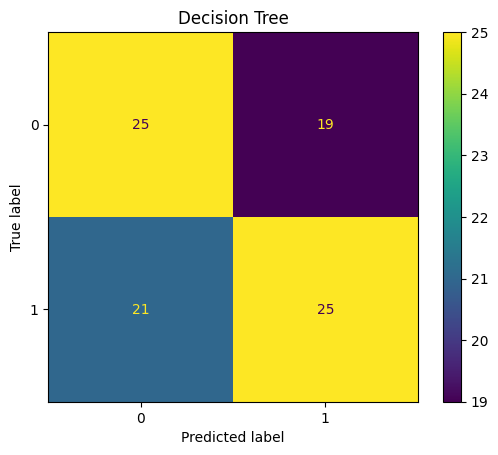

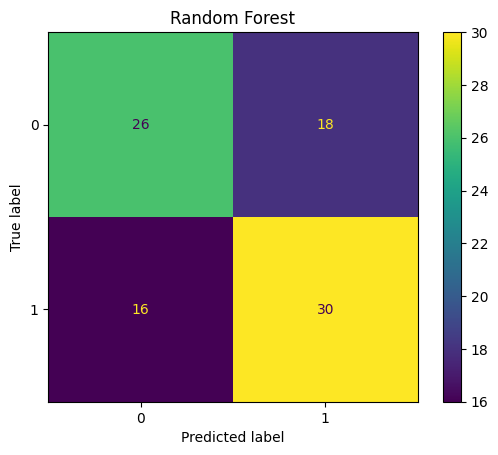


 Cross Validatio
Decision Tree: 0.5200000000000001
Random Forest: 0.5866666666666667


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
np.random.seed(42)

n_samples=300

data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'Crop Type':np.random.choice(['Wheat','Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
}
df=pd.DataFrame(data)

def irrigate_rule(row):
  if row['Soil']=='Dry'and row["Weather"]!='Rainy':
    base='Yes'
  elif row['Soil']=='Wet':
    base='No'
  else:
    base=random.choice(['Yes','No'])
  if random.random()<0.2:
    return 'No' if base =='Yes' else 'Yes'
  return base


df['irrigate']=df.apply(irrigate_rule,axis=1)

le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

X=df.drop('irrigate',axis=1)
y=df['irrigate']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)


dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

rf_model=RandomForestClassifier(n_estimators=100,max_features='sqrt',random_state=42)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)


dt_acc=accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\nAccuracy Comparision")
print("Decision Tree Accuracy:",dt_acc)
print("Random Forest Accuracy:",rf_acc)


cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])
print("\nDecision Tree Confusion Matrix:",cm_dt)
print("\nRandom forest Confusion Matrix:",cm_rf)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title("Random Forest")
plt.show()

dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\n Cross Validatio")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())